In [4]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
importlib.reload(config)  # long-lived kernels otherwise keep a config imported before recent edits
from viz_style import apply_style
apply_style()

ENGINE_PATH = "./engine_state_mixed_tau9_nopool_20260728"

In [5]:
import anndata as ad
import pickle
from scipy.sparse import issparse

def load_hc(h5ad_path=config.H5AD_PATH, engine_dir=ENGINE_PATH):
    adata = ad.read_h5ad(h5ad_path)
    m = ((adata.obs["QC_Passed"] == True) & 
         (adata.obs["Phenotype_Processed"].notna()) &
         (adata.obs["Phenotype_Processed"] != "Unknown") &
         (adata.obs["broad_protocol_category"] != "Exome-based (EB)"))
    a = adata[m]
    is_hc = (a.obs["Phenotype_Processed"].astype(str) == "Healthy Control").values
    is_pc = (a.var["GeneType"] == "protein_coding").values
    batch = a.obs[config.STRATIFY_COL].astype(object).fillna("NA").astype(str).values[is_hc]
   
    bsize = pd.Series(batch).value_counts()
    small = set(bsize.loc[lambda v: v < config.MIN_HC_BATCH_SIZE].index)
    keep = np.array([b not in small for b in batch])
    with open(f"{engine_dir}/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    X = a.obs[config.BIAS_COLUMNS].values.astype(np.float64)[is_hc][keep]
    Xs = scaler.transform(X)
    Y = a.X.toarray() if issparse(a.X) else np.asarray(a.X)
    Y = np.round(Y[is_hc][:, is_pc][keep]).astype(np.float64)
    names = np.array(a.var_names[is_pc].tolist())
    return Xs, Y, batch[keep], names

Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}
print(f"HC samples used: {Xs.shape[0]} (batches >= {config.MIN_HC_BATCH_SIZE}: {len(set(batch))})")

summ = pd.read_csv(ENGINE_PATH + "/training_summary.csv")
summ = summ[summ.gene.isin(gmap)].copy()
cols = summ.gene.map(gmap).values

mean_c = Y[:, cols].mean(0)
max_c = Y[:, cols].max(0)
zero_frac = (Y[:, cols] == 0).mean(0)
nz = (Y[:, cols] != 0).sum(0)
var_c = Y[:, cols].var(0)

summ = summ.assign(
    mean_hc=mean_c, 
    max_hc=max_c, 
    nz=nz, 
    zero_frac=zero_frac, 
    var_hc=var_c,
    max_over_mean=max_c / np.maximum(mean_c, 1e-9)
)
summ['stage_failure'] = summ['stage'] + '_' + summ['ok'].astype(str)
print("Total analyzed genes:", len(summ))

HC samples used: 676 (batches >= 5: 22)
Total analyzed genes: 20097


In [6]:
# nz 구간 세분화 (Low count 영역 촘촘하게 + High count 영역까지 광범위하게)
bins = [-1, 0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400, 500, 600, Y.shape[0]]
labels = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-75', '76-100', 
          '101-150', '151-200', '201-300', '301-400', '401-500', '501-600', '601+']

summ['nz_group'] = pd.cut(summ['nz'], bins=bins, labels=labels)

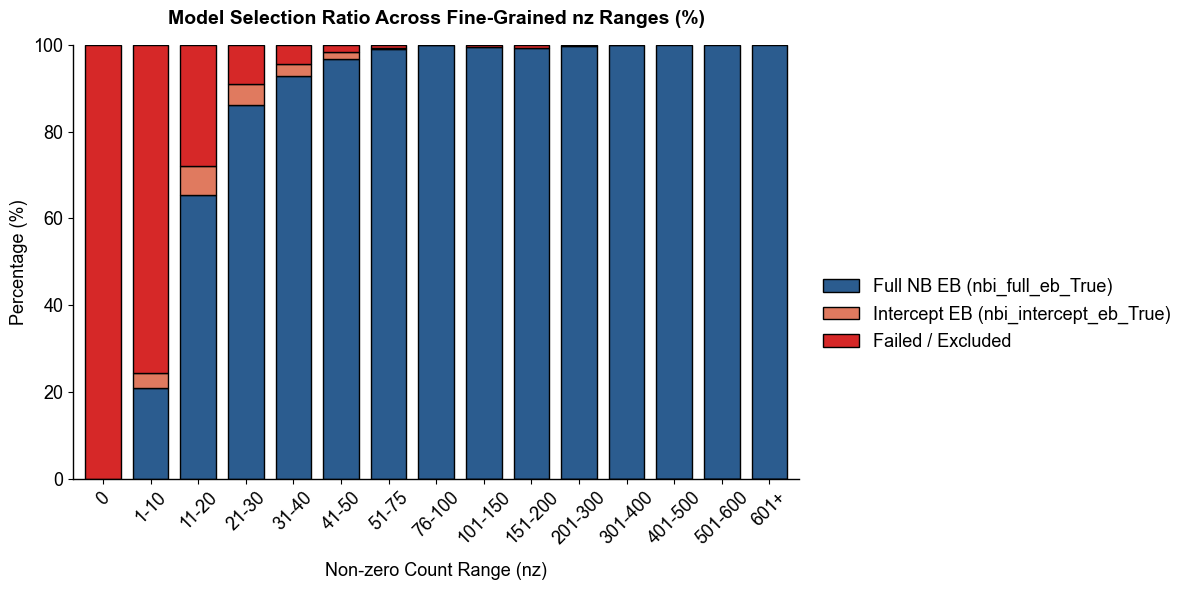

,stage_failure,n,nz_med,mean_hc_med,max_hc_med,zero_frac_med,max_over_mean_med,tau2_med
0,nbi_full_eb_True,19011,536.0,33.745562,858.0,0.207101,26.704289,4.483271e-02
1,nbi_intercept_eb_False,967,6.0,0.025148,6.0,0.991124,270.400000,6.736933e-09
2,nbi_intercept_eb_True,119,17.0,0.099112,18.0,0.974852,205.739130,1.017487e-08


In [7]:
stage_order = ['nbi_full_eb_True', 'nbi_intercept_eb_True', 'nbi_intercept_eb_False']
stage_labels = {
    'nbi_full_eb_True': 'Full NB EB (nbi_full_eb_True)',
    'nbi_intercept_eb_True': 'Intercept EB (nbi_intercept_eb_True)',
    'nbi_intercept_eb_False': 'Failed / Excluded'
}

ct_pct = pd.crosstab(summ['nz_group'], summ['stage_failure'], normalize='index') * 100
for stage in stage_order:
    if stage not in ct_pct.columns:
        ct_pct[stage] = 0.0
ct_pct = ct_pct[stage_order]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2b5c8f', '#e07a5f', '#d62828']

ct_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',
    linewidth=1,
    width=0.75
)

ax.set_title('Model Selection Ratio Across Fine-Grained nz Ranges (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Non-zero Count Range (nz)', labelpad=10)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
ax.legend([stage_labels[s] for s in stage_order], bbox_to_anchor=(1.01, 0.5), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

table_summary = summ.groupby("stage_failure").agg(
    n=("gene", "size"),
    nz_med=("nz", "median"),
    mean_hc_med=("mean_hc", "median"),
    max_hc_med=("max_hc", "median"),
    zero_frac_med=("zero_frac", "median"),
    max_over_mean_med=("max_over_mean", "median"),
    tau2_med=("tau2", "median")
).reset_index()

display(table_summary)

/tmp/ipykernel_691136/1407147151.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,


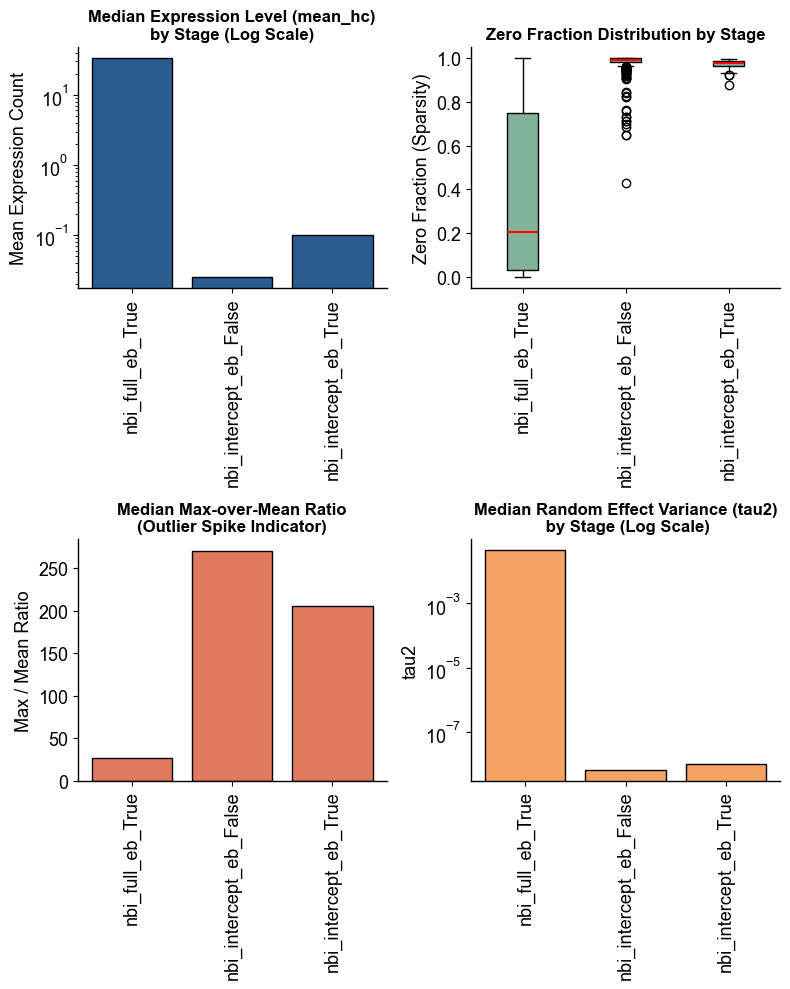

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 10))

stages = table_summary['stage_failure']
means = table_summary['mean_hc_med']

# 1. Median Mean Expression by Stage
axes[0, 0].bar(stages, means, color='#2b5c8f', edgecolor='black')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Median Expression Level (mean_hc)\nby Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Mean Expression Count')
axes[0, 0].tick_params(axis='x', rotation=90)

# 2. Zero Fraction Boxplot
stage_data = [summ[summ['stage_failure'] == s]['zero_frac'].values for s in stages]
axes[0, 1].boxplot(stage_data, labels=stages, patch_artist=True,
                   boxprops=dict(facecolor='#81b29a', color='black'),
                   medianprops=dict(color='red', linewidth=1.5))
axes[0, 1].set_title('Zero Fraction Distribution by Stage', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Zero Fraction (Sparsity)')
axes[0, 1].tick_params(axis='x', rotation=90)

# 3. Max / Mean Outlier Spike Ratio
axes[1, 0].bar(stages, table_summary['max_over_mean_med'], color='#e07a5f', edgecolor='black')
axes[1, 0].set_title('Median Max-over-Mean Ratio\n(Outlier Spike Indicator)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Max / Mean Ratio')
axes[1, 0].tick_params(axis='x', rotation=90)

# 4. Tau2 (Random Effect Variance) Median
axes[1, 1].bar(stages, table_summary['tau2_med'], color='#f4a261', edgecolor='black')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Median Random Effect Variance (tau2)\n by Stage (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('tau2')
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [11]:
import os
import sys
import types
import pickle
import anndata as ad
from scipy.sparse import issparse

# 0. Fix pickle class mapping error for MixedEffectsModeling.model_engine_mixed
from MixedEffectsModeling.core.marginal_rqr import marginal_nb_loglik
import MixedEffectsModeling.core.model_engine_mixed as model_engine_mixed
sys.modules['MixedEffectsModeling.model_engine_mixed'] = model_engine_mixed

# 1. Load data & fitted objects
Xs, Y, batch, gene_names = load_hc()
gmap = {g: i for i, g in enumerate(gene_names)}

with open(ENGINE_PATH+'/genes.pkl', 'rb') as f:
    genes_fit = pickle.load(f)

X_design = np.hstack([np.ones((Xs.shape[0], 1)), Xs])

In [13]:
from scipy.stats import nbinom
from numpy.polynomial.hermite_e import hermegauss
from tqdm.auto import tqdm
from MixedEffectsModeling.core.marginal_rqr import marginal_nb_rqr
from MixedEffectsModeling.core.calibration import gene_shash_calibration

_HG_NODES, _HG_WEIGHTS = hermegauss(7)
_HG_WEIGHTS = _HG_WEIGHTS / _HG_WEIGHTS.sum()
_TAU2_EPS = 1e-12
PPC_N_REPS = 500
SHASH_MAX_N = 3000
CKPT_PATH = ENGINE_PATH+'/train_fitness_results_partial.pkl'
CKPT_EVERY = 1000
RESULTS_COLS_V2 = {'rqr_msq', 'rqr_med_z2', 'obs_var', 'pred_var', 'n_hc'}

def nb_marginal_mean_var(mu, alpha, tau2):
    # E[Y]=mu*exp(tau2/2); Var[Y] via E[Y^2|b]=mu*exp(b)+(1+alpha)*(mu*exp(b))^2,
    # integrated analytically over the lognormal random intercept (closed form, no quadrature).
    if tau2 < _TAU2_EPS:
        return mu, mu + alpha * mu ** 2
    mean = mu * np.exp(tau2 / 2)
    ey2 = mu * np.exp(tau2 / 2) + (1 + alpha) * mu ** 2 * np.exp(2 * tau2)
    return mean, ey2 - mean ** 2

def nb_marginal_pmf0(mu, alpha, tau2):
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    if tau2 < _TAU2_EPS:
        p_ = np.clip(n_ / (n_ + mu), 1e-8, 1 - 1e-8)
        return nbinom.pmf(0, n_, p_)
    sd = np.sqrt(tau2)
    total = np.zeros_like(mu)
    for node, w in zip(_HG_NODES, _HG_WEIGHTS):
        mu_b = mu * np.exp(sd * node)
        p_ = np.clip(n_ / (n_ + mu_b), 1e-8, 1 - 1e-8)
        total += w * nbinom.pmf(0, n_, p_)
    return total

def simulate_mixed_many(mu, alpha, tau2, n_reps, seed):
    # posterior-predictive replicates matching marginal_rqr's mixture assumption:
    # b ~ N(0,tau2) per (rep, sample), mu_b = mu*exp(b), y_rep ~ NB(mu_b, alpha).
    rng = np.random.default_rng(seed)
    n_obs = len(mu)
    if tau2 < _TAU2_EPS:
        mu_b = np.broadcast_to(mu, (n_reps, n_obs))
    else:
        b = rng.normal(0.0, np.sqrt(tau2), size=(n_reps, n_obs))
        mu_b = np.clip(mu[None, :] * np.exp(b), 1e-8, 1e10)
    n_ = np.broadcast_to(1.0 / np.maximum(alpha, 1e-8), (n_reps, n_obs))
    p_ = np.clip(n_ / (n_ + mu_b), 1e-10, 1 - 1e-10)
    return rng.negative_binomial(n_, p_)

def _cache_valid(cols, n_hc):
    return RESULTS_COLS_V2.issubset(cols) and int(n_hc) == Y.shape[0]

# 2. Evaluate In-Sample Fit, PPC & SHASH Calibration for all genes
df_res = None
if os.path.exists(ENGINE_PATH+'/train_fitness_results.pkl'):
    with open(ENGINE_PATH+'/train_fitness_results.pkl', 'rb') as f:
        df_res = pickle.load(f)
    if len(df_res) == 0 or not _cache_valid(set(df_res.columns), df_res['n_hc'].iloc[0] if 'n_hc' in df_res.columns else -1):
        df_res = None  # stale schema or different HC cohort, recompute

if df_res is None:
    results = []
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH, 'rb') as f:
            results = pickle.load(f)
        if results and not _cache_valid(set(results[0].keys()), results[0].get('n_hc', -1)):
            results = []
    done = {r['gene'] for r in results}
    genes_todo = [g for g in summ['gene'].values if g in genes_fit and g not in done]

    for i, g in enumerate(tqdm(genes_todo, desc='in-sample fit')):
        fit_obj = genes_fit[g]
        y = Y[:, gmap[g]]
        n_obs = len(y)
        obs_mean = float(y.mean())
        obs_var = float(y.var())
        obs_nz = int((y > 0).sum())
        if not fit_obj.ok:
            mu = np.full(n_obs, np.maximum(obs_mean, 1e-9))
            alpha = np.full(n_obs, 1.0)
            tau2 = 0.0
        else:
            mu = np.exp(X_design @ np.nan_to_num(fit_obj.mu_coef, nan=0.0)) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(obs_mean, 1e-9))
            if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
                alpha = np.exp(-X_design @ np.nan_to_num(fit_obj.disp_coef, nan=0.0))
            elif fit_obj.trend_alpha is not None:
                alpha = np.full(n_obs, fit_obj.trend_alpha)
            else:
                alpha = np.full(n_obs, 1.0)
            tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0

        mu_marg, var_marg = nb_marginal_mean_var(mu, alpha, tau2)
        pred_zero_frac = float(np.mean(nb_marginal_pmf0(mu, alpha, tau2)))
        obs_zero_frac = float((y == 0).mean())
        ll_per_sample = marginal_nb_loglik(y, mu, alpha, tau2)
        avg_loglik = float(np.mean(ll_per_sample))
        pred_mean = float(np.mean(mu_marg))
        pred_var = float(np.mean(var_marg))

        pearson_chi2 = float(np.sum(((y - mu_marg) ** 2) / np.maximum(var_marg, 1e-8)) / n_obs)

        seed = 1000 + i
        y_rep = simulate_mixed_many(mu, alpha, tau2, PPC_N_REPS, seed)
        rep_mean = y_rep.mean(axis=1)
        rep_var = y_rep.var(axis=1)
        rep_zero_frac = (y_rep == 0).mean(axis=1)
        rep_chi2 = np.mean((y_rep - mu_marg[None, :]) ** 2 / np.maximum(var_marg[None, :], 1e-8), axis=1)
        ppc_p_mean = float(np.mean(rep_mean >= obs_mean))
        ppc_p_var = float(np.mean(rep_var >= obs_var))
        ppc_p_zero = float(np.mean(rep_zero_frac >= obs_zero_frac))
        ppc_p_chi2 = float(np.mean(rep_chi2 >= pearson_chi2))

        q25, q50, q90, q95, q99 = np.percentile(y_rep, [25, 50, 90, 95, 99], axis=0)
        cov_25 = float(np.mean(y <= q25))
        cov_50 = float(np.mean(y <= q50))
        cov_90 = float(np.mean(y <= q90))
        cov_95 = float(np.mean(y <= q95))
        cov_99 = float(np.mean(y <= q99))

        z = marginal_nb_rqr(y, mu, alpha, tau2, seed=seed + 1)
        z_fin = z[np.isfinite(z)]

        rqr_msq = float(np.mean(z_fin ** 2)) if len(z_fin) else np.nan
        rqr_med_z2 = float(np.median(z_fin ** 2)) if len(z_fin) else np.nan

        z_sub = z if n_obs <= SHASH_MAX_N else np.random.default_rng(seed).choice(z, SHASH_MAX_N, replace=False)
        calib = gene_shash_calibration(z_sub)

        results.append({
            'gene': g,
            'stage_failure': fit_obj.stage + '_' + str(fit_obj.ok),
            'nz': obs_nz,
            'n_hc': n_obs,
            'obs_mean': obs_mean,
            'pred_mean': pred_mean,
            'obs_var': obs_var,
            'pred_var': pred_var,
            'obs_zero_frac': obs_zero_frac,
            'pred_zero_frac': pred_zero_frac,
            'zero_diff': pred_zero_frac - obs_zero_frac,
            'pearson_chi2': pearson_chi2,
            'rqr_msq': rqr_msq,
            'rqr_med_z2': rqr_med_z2,
            'avg_loglik': avg_loglik,
            'cov_25': cov_25, 'cov_50': cov_50, 'cov_90': cov_90, 'cov_95': cov_95, 'cov_99': cov_99,
            'ppc_p_mean': ppc_p_mean, 'ppc_p_var': ppc_p_var, 'ppc_p_zero': ppc_p_zero, 'ppc_p_chi2': ppc_p_chi2,
            **calib,
        })

        if (i + 1) % CKPT_EVERY == 0:
            with open(CKPT_PATH, 'wb') as f:
                pickle.dump(results, f)

    df_res = pd.DataFrame(results)
    with open(ENGINE_PATH + '/train_fitness_results.pkl', 'wb') as f:
        pickle.dump(df_res, f)
    if os.path.exists(CKPT_PATH):
        os.remove(CKPT_PATH)

In [14]:
# 3. SHASH Calibration Gain vs Raw Skew/Kurtosis
calib_df = df_res[df_res['shash_ok'] & df_res['stage_failure'].str.endswith('True')].copy()
calib_df['fdr_gain'] = calib_df['naive_fdr_reject_rate'] - calib_df['corr_fdr_reject_rate']
calib_df['exceed_gain'] = calib_df['naive_exceed'] - calib_df['shash_exceed']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(calib_df['raw_kurtosis'], calib_df['fdr_gain'], s=6, alpha=0.25, color='#2b5c8f')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Raw (naive) excess kurtosis')
axes[0].set_ylabel('naive_fdr_reject_rate - corr_fdr_reject_rate')
axes[0].set_title('FDR Correction Gain vs Excess Kurtosis\n(in-sample RQR)', fontsize=11, fontweight='bold')

axes[1].scatter(calib_df['raw_skew'].abs(), calib_df['exceed_gain'], s=6, alpha=0.25, color='#e07a5f')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('|Raw (naive) skewness|')
axes[1].set_ylabel('naive_exceed - shash_exceed (95% exceedance)')
axes[1].set_title('Exceedance Correction Gain vs |Skewness|', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"shash_ok genes: {len(calib_df)} / {len(df_res)}")
print(f"corr(raw_kurtosis, fdr_gain) = {calib_df['raw_kurtosis'].corr(calib_df['fdr_gain']):.3f}")
print(f"corr(|raw_skew|, exceed_gain) = {calib_df['raw_skew'].abs().corr(calib_df['exceed_gain']):.3f}")

shash_ok genes: 19128 / 20097
corr(raw_kurtosis, fdr_gain) = 0.492
corr(|raw_skew|, exceed_gain) = -0.168


/tmp/ipykernel_691136/890994635.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


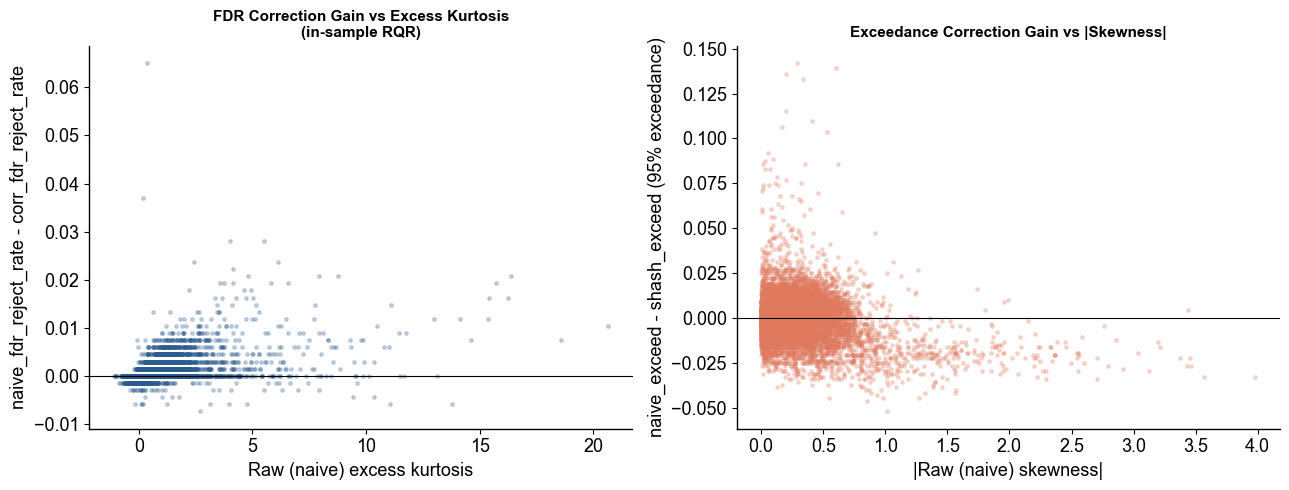

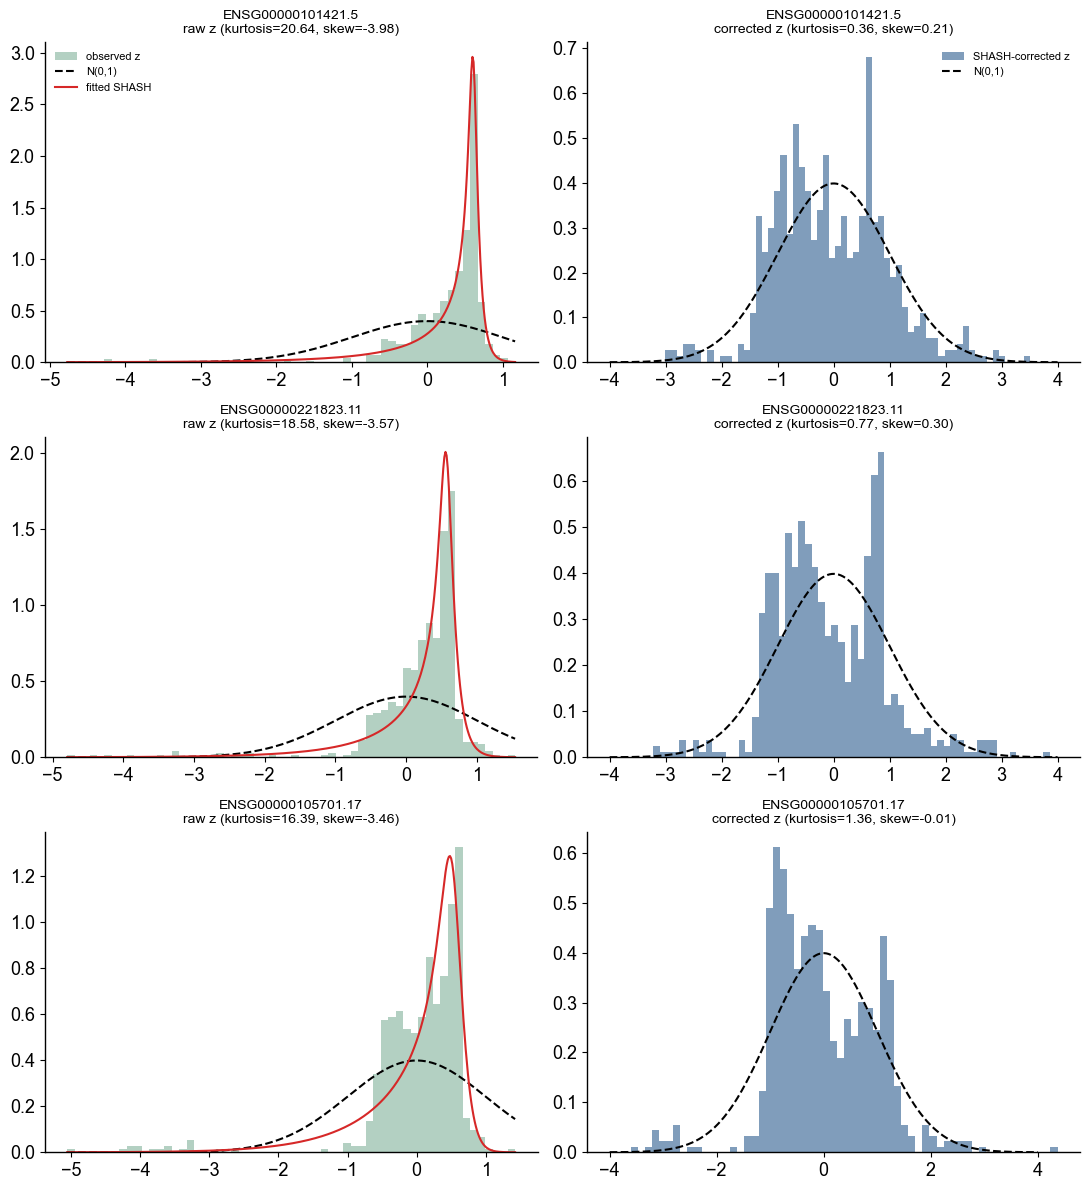

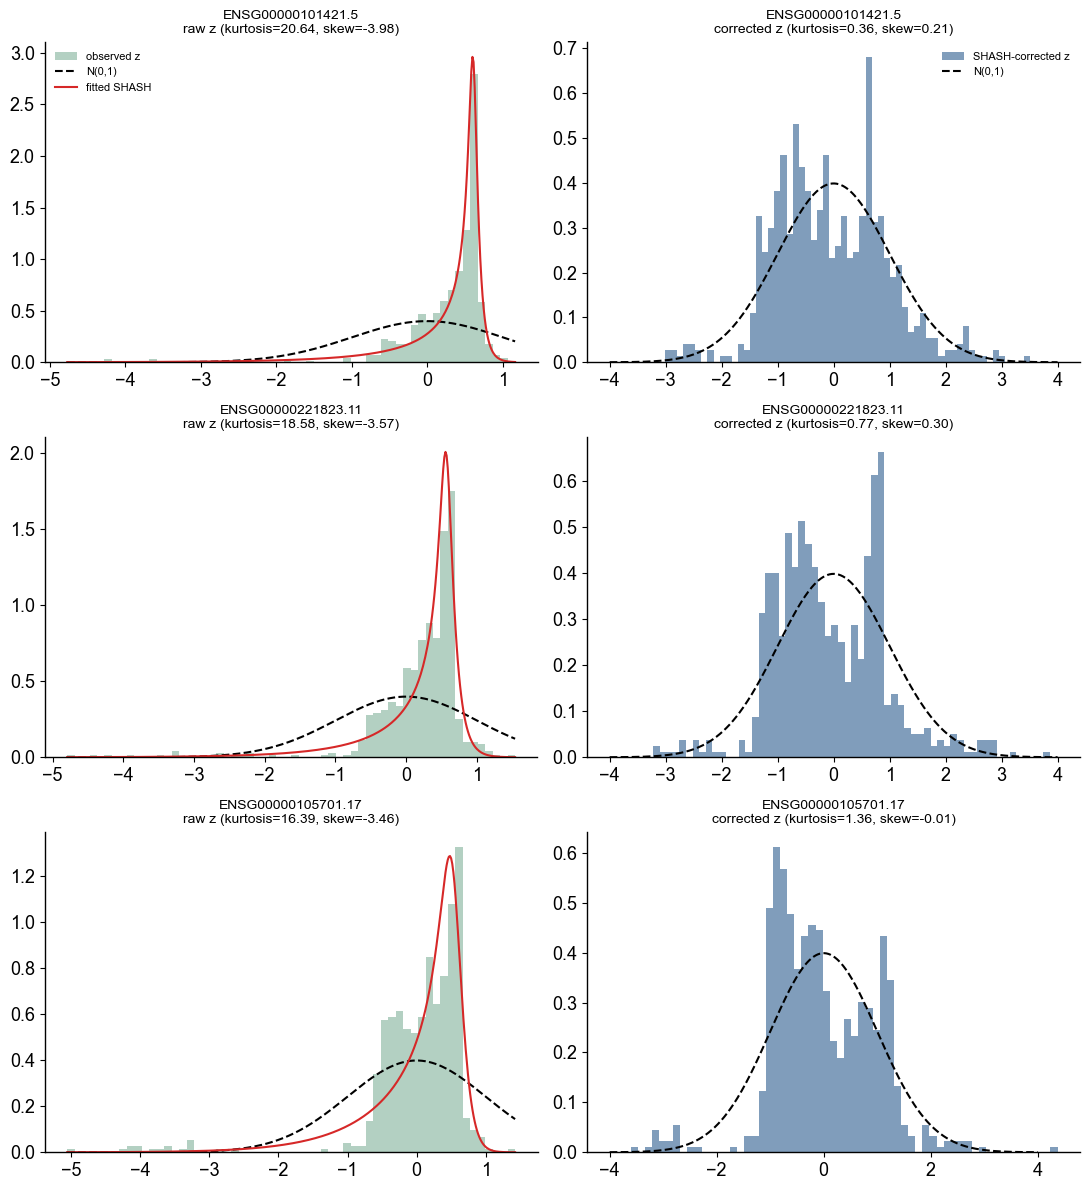

In [16]:
# 4. Example Genes: Raw vs SHASH-Corrected z Distribution (most extreme raw kurtosis)
%matplotlib inline
from MixedEffectsModeling.core.shash import shash_logpdf, shash_transform_to_z
from scipy.stats import norm as _norm

def _gene_mu_alpha_tau2(fit_obj, obs_mean, n_obs):
    if not fit_obj.ok:
        return np.full(n_obs, np.maximum(obs_mean, 1e-9)), np.full(n_obs, 1.0), 0.0
    mu = np.exp(X_design @ np.nan_to_num(fit_obj.mu_coef, nan=0.0)) if fit_obj.mu_coef is not None else np.full(n_obs, np.maximum(obs_mean, 1e-9))
    if fit_obj.disp_coef is not None and not np.all(np.isnan(fit_obj.disp_coef)):
        alpha = np.exp(-X_design @ np.nan_to_num(fit_obj.disp_coef, nan=0.0))
    elif fit_obj.trend_alpha is not None:
        alpha = np.full(n_obs, fit_obj.trend_alpha)
    else:
        alpha = np.full(n_obs, 1.0)
    tau2 = fit_obj.tau2 if fit_obj.tau2 is not None else 0.0
    return mu, alpha, tau2

top_genes = calib_df.assign(abs_kurt=calib_df['raw_kurtosis'].abs()).nlargest(3, 'abs_kurt')

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
for row, (_, rec) in enumerate(top_genes.iterrows()):
    g = rec['gene']
    fit_obj = genes_fit[g]
    y = Y[:, gmap[g]]
    n_obs = len(y)
    obs_mean = float(y.mean())
    mu, alpha, tau2 = _gene_mu_alpha_tau2(fit_obj, obs_mean, n_obs)
    z = marginal_nb_rqr(y, mu, alpha, tau2, seed=7)
    z = z[np.isfinite(z)]
    xi, eta, eps, delta = rec['shash_xi'], rec['shash_eta'], rec['shash_eps'], rec['shash_delta']
    z_corr = shash_transform_to_z(z, xi, eta, eps, delta)

    grid = np.linspace(z.min(), z.max(), 400)
    ax = axes[row, 0]
    ax.hist(z, bins=60, density=True, color='#81b29a', alpha=0.6, label='observed z')
    ax.plot(grid, _norm.pdf(grid), color='black', linewidth=1.5, linestyle='--', label='N(0,1)')
    ax.plot(grid, np.exp(shash_logpdf(grid, xi, eta, eps, delta)), color='#d62828', linewidth=1.5, label='fitted SHASH')
    ax.set_title(f'{g}\nraw z (kurtosis={rec["raw_kurtosis"]:.2f}, skew={rec["raw_skew"]:.2f})', fontsize=10)
    if row == 0:
        ax.legend(frameon=False, fontsize=8)

    ax2 = axes[row, 1]
    grid_c = np.linspace(-4, 4, 400)
    ax2.hist(z_corr, bins=60, density=True, color='#2b5c8f', alpha=0.6, label='SHASH-corrected z')
    ax2.plot(grid_c, _norm.pdf(grid_c), color='black', linewidth=1.5, linestyle='--', label='N(0,1)')
    ax2.set_title(f'{g}\ncorrected z (kurtosis={rec["corrected_kurtosis"]:.2f}, skew={rec["corrected_skew"]:.2f})', fontsize=10)
    if row == 0:
        ax2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

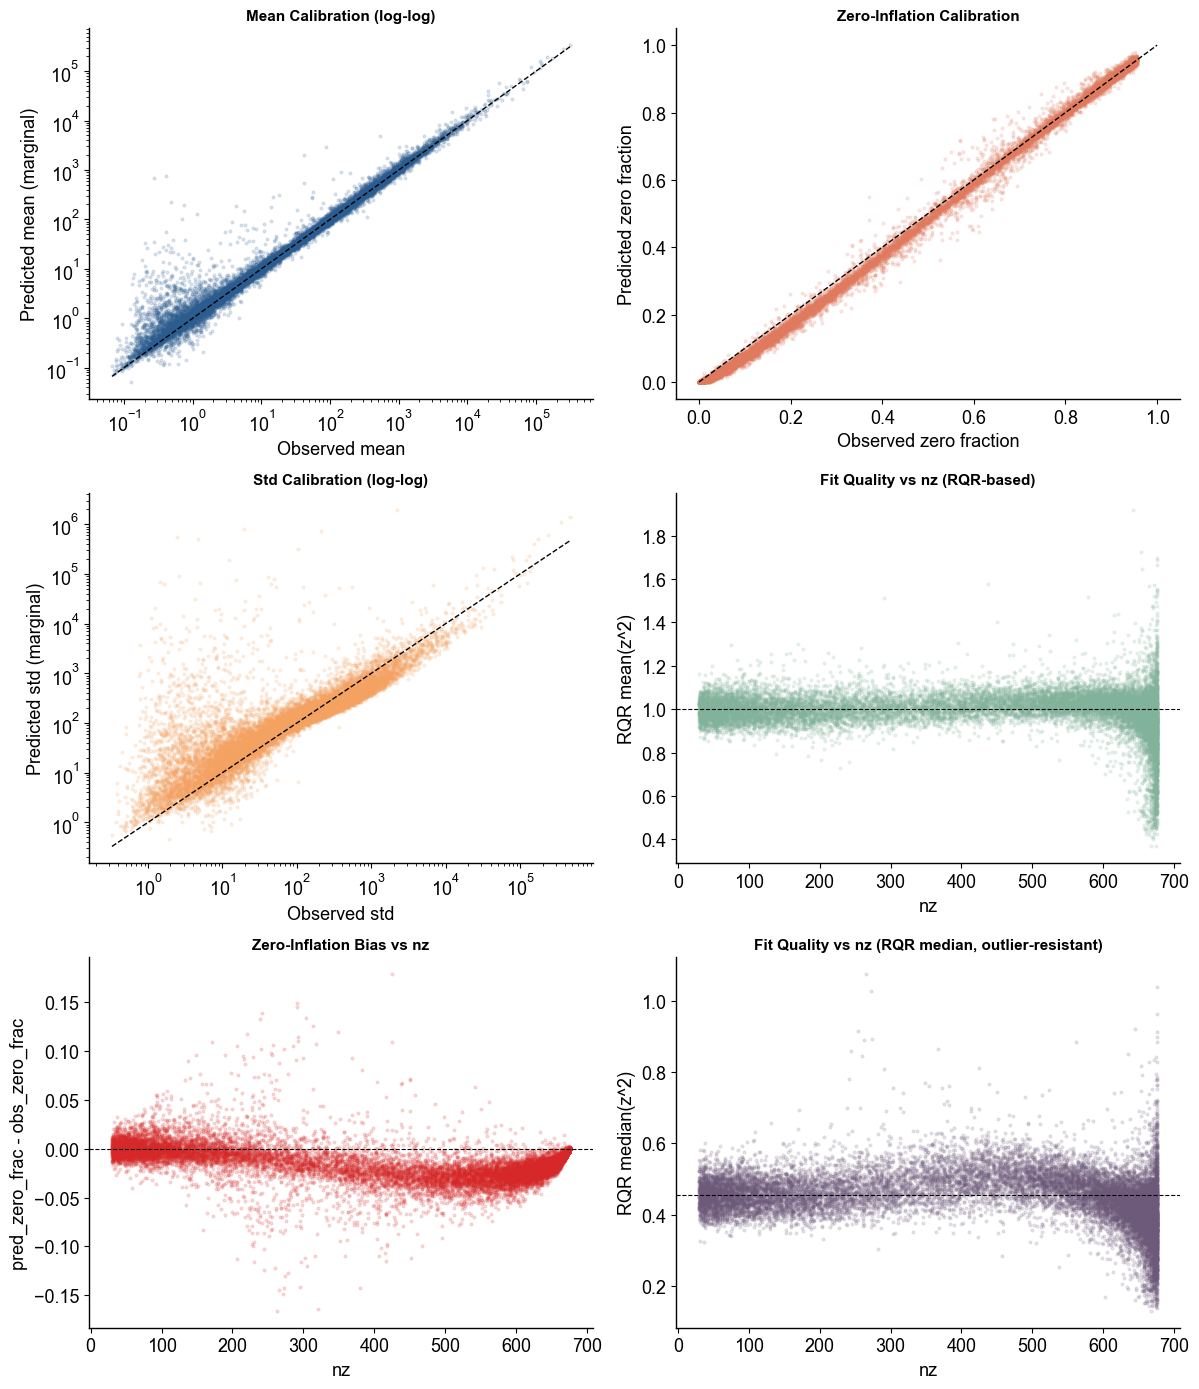

n genes plotted: 18031 (dropped 1099 genes with nz < 30)
median rqr_msq: 1.002 (median rqr_med_z2: 0.448)
median |zero_diff|: 0.0134
median obs_var/pred_var ratio: 0.776
median obs_std/pred_std ratio: 0.881
[legacy] median pearson_chi2 (nz>=30 subset): 0.820, max: 1838033003.7 vs full-set max: 1.84e+09


In [17]:
# 5. PPC Scatter: predicted vs observed (in-sample)
# nz < trend_min_nz (30) genes are dropped from these diagnostic plots: mu_coef/disp_coef are
# fit on so few nonzero observations that a handful of samples get extrapolated near mu~0,
# producing observed-mean/pred-mean ratios and residual/variance ratios of several orders of
# magnitude that swamp the scatter and axis scaling for the other ~19k well-fit genes.
NZ_DIAG_MIN = config.SPIKE_PARAMS["trend_min_nz"]
ok_res_all = df_res[df_res['stage_failure'].str.endswith('True')].copy()
ok_res = ok_res_all[ok_res_all['nz'] >= NZ_DIAG_MIN].copy()

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

axes[0, 0].scatter(ok_res['obs_mean'], ok_res['pred_mean'], s=4, alpha=0.15, color='#2b5c8f')
lims = [max(ok_res['obs_mean'].min(), 1e-3), ok_res['obs_mean'].max()]
axes[0, 0].plot(lims, lims, color='black', linewidth=1, linestyle='--')
axes[0, 0].set_xscale('log'); axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Observed mean'); axes[0, 0].set_ylabel('Predicted mean (marginal)')
axes[0, 0].set_title('Mean Calibration (log-log)', fontsize=11, fontweight='bold')

axes[0, 1].scatter(ok_res['obs_zero_frac'], ok_res['pred_zero_frac'], s=4, alpha=0.15, color='#e07a5f')
axes[0, 1].plot([0, 1], [0, 1], color='black', linewidth=1, linestyle='--')
axes[0, 1].set_xlabel('Observed zero fraction'); axes[0, 1].set_ylabel('Predicted zero fraction')
axes[0, 1].set_title('Zero-Inflation Calibration', fontsize=11, fontweight='bold')

# STD instead of raw VAR: NB2 variance ~ mu^2, so VAR spans many more orders of magnitude than
# the mean and visually dominates/distorts the scatter; STD = sqrt(VAR) halves the log-scale
# spread and puts this panel on a comparable footing to the mean-calibration panel above.
obs_std, pred_std = np.sqrt(ok_res['obs_var']), np.sqrt(ok_res['pred_var'])
axes[1, 0].scatter(obs_std, pred_std, s=4, alpha=0.15, color='#f4a261')
slims = [max(obs_std.min(), 1e-2), obs_std.max()]
axes[1, 0].plot(slims, slims, color='black', linewidth=1, linestyle='--')
axes[1, 0].set_xscale('log'); axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Observed std'); axes[1, 0].set_ylabel('Predicted std (marginal)')
axes[1, 0].set_title('Std Calibration (log-log)', fontsize=11, fontweight='bold')

# rqr_msq = mean(z^2) of the RQR z-scores, z clipped at |z|<~5.6 by construction (RQR_EPS=1e-8
# in marginal_rqr.py) -- a bounded, PIT-based analogue of reduced pearson_chi2 (df=1, ~1 under
# a correct model) that a single extrapolated low-nz observation cannot blow up. Linear scale:
# unlike pearson_chi2 this never spans orders of magnitude, so a log axis would only exaggerate
# noise around 1 instead of showing real miscalibration.
axes[1, 1].scatter(ok_res['nz'], ok_res['rqr_msq'], s=4, alpha=0.15, color='#81b29a')
axes[1, 1].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_xlabel('nz'); axes[1, 1].set_ylabel('RQR mean(z^2)')
axes[1, 1].set_title('Fit Quality vs nz (RQR-based)', fontsize=11, fontweight='bold')

axes[2, 0].scatter(ok_res['nz'], ok_res['zero_diff'], s=4, alpha=0.15, color='#d62828')
axes[2, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2, 0].set_xlabel('nz'); axes[2, 0].set_ylabel('pred_zero_frac - obs_zero_frac')
axes[2, 0].set_title('Zero-Inflation Bias vs nz', fontsize=11, fontweight='bold')

axes[2, 1].scatter(ok_res['nz'], ok_res['rqr_med_z2'], s=4, alpha=0.15, color='#6d597a')
axes[2, 1].axhline(0.4549, color='black', linewidth=0.8, linestyle='--')  # median of chi2(df=1)
axes[2, 1].set_xlabel('nz'); axes[2, 1].set_ylabel('RQR median(z^2)')
axes[2, 1].set_title('Fit Quality vs nz (RQR median, outlier-resistant)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"n genes plotted: {len(ok_res)} (dropped {len(ok_res_all) - len(ok_res)} genes with nz < {NZ_DIAG_MIN})")
print(f"median rqr_msq: {ok_res['rqr_msq'].median():.3f} (median rqr_med_z2: {ok_res['rqr_med_z2'].median():.3f})")
print(f"median |zero_diff|: {ok_res['zero_diff'].abs().median():.4f}")
print(f"median obs_var/pred_var ratio: {(ok_res['obs_var'] / ok_res['pred_var']).median():.3f}")
print(f"median obs_std/pred_std ratio: {(np.sqrt(ok_res['obs_var']) / np.sqrt(ok_res['pred_var'])).median():.3f}")
print(f"[legacy] median pearson_chi2 (nz>={NZ_DIAG_MIN} subset): {ok_res['pearson_chi2'].median():.3f}, "
      f"max: {ok_res['pearson_chi2'].max():.1f} vs full-set max: {ok_res_all['pearson_chi2'].max():.3g}")


/tmp/ipykernel_691136/1274969156.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


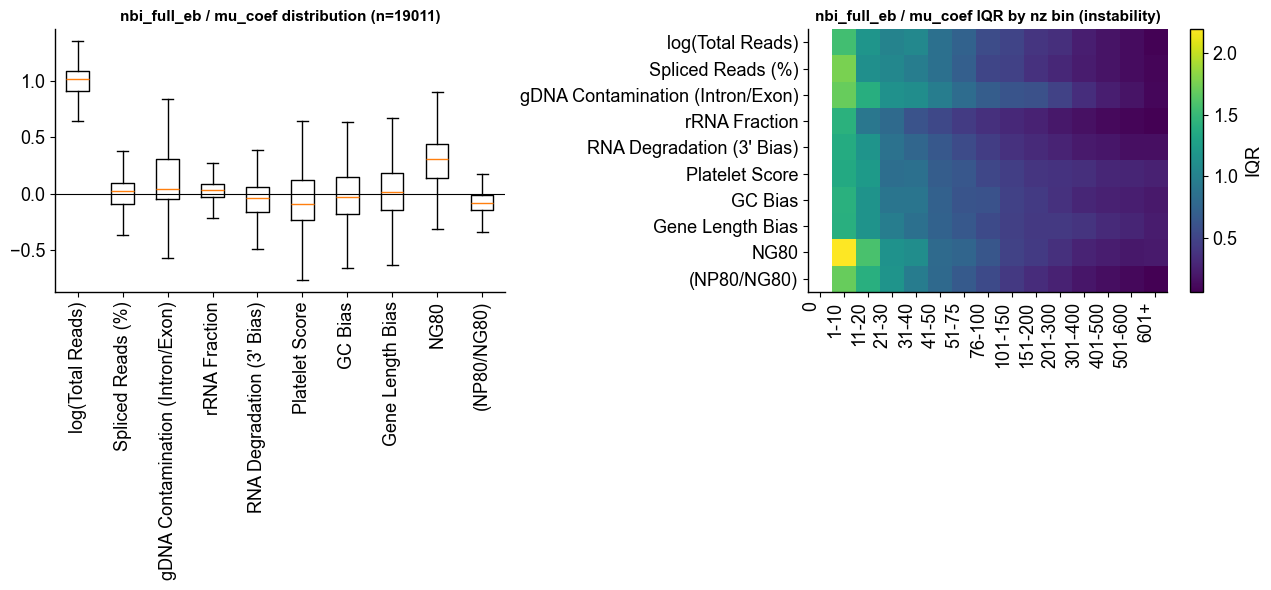

/tmp/ipykernel_691136/1274969156.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


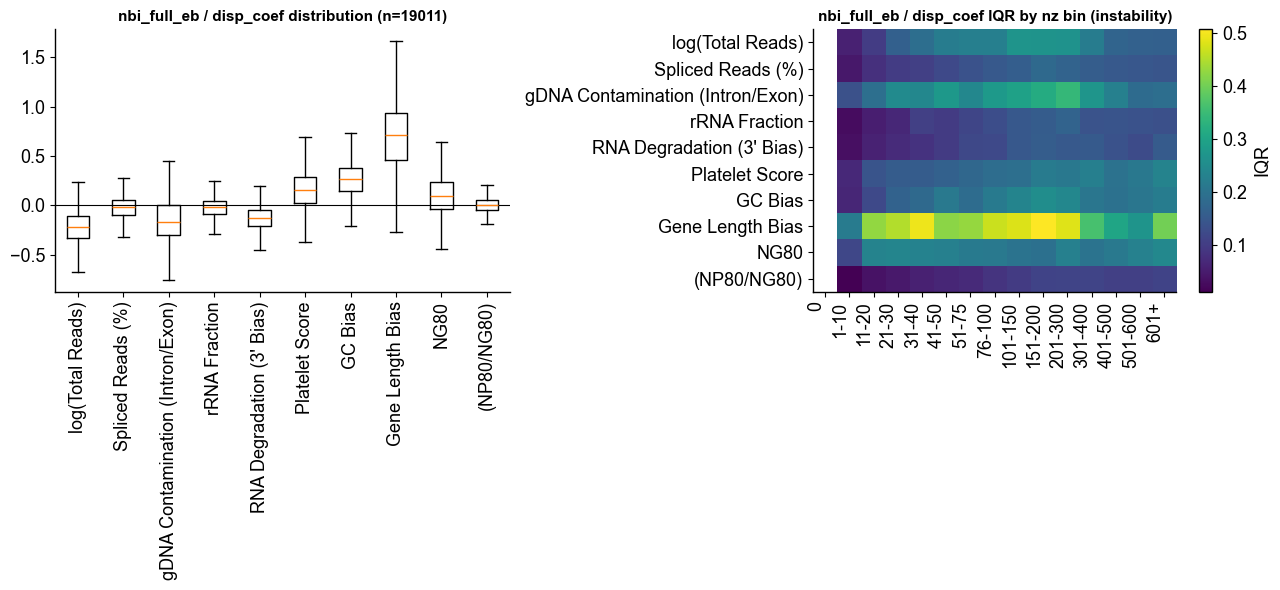

/tmp/ipykernel_691136/1274969156.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)


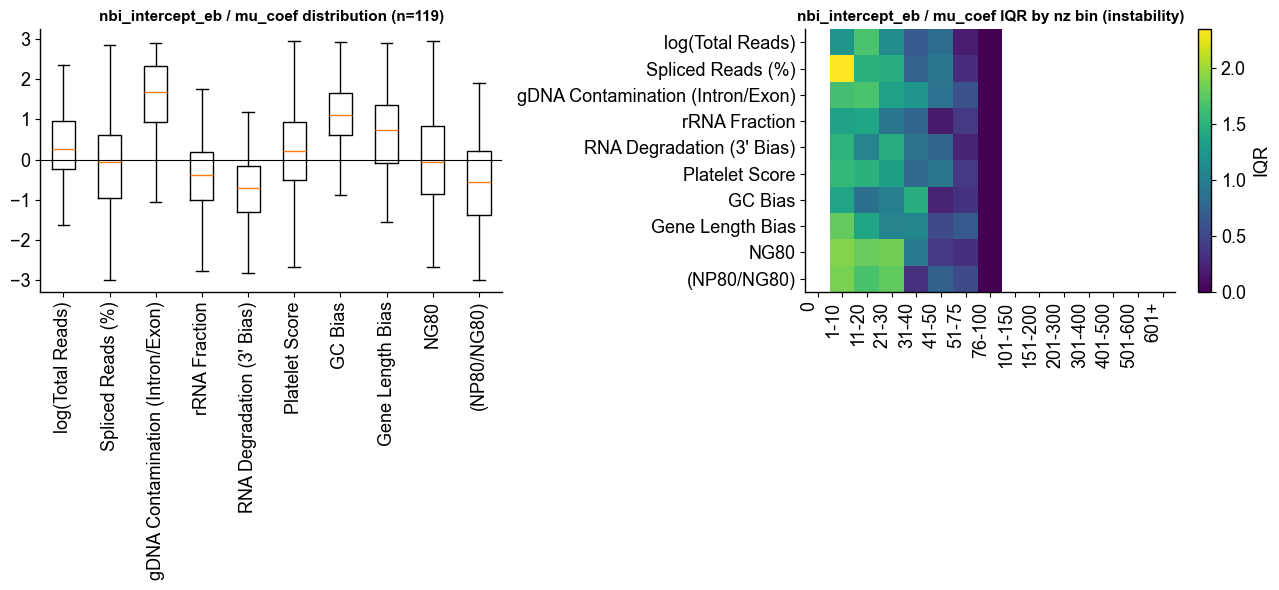

In [18]:
# 6. Parameter-Level Analysis: coefficients per stage, distribution + nz-level variability
# Intercept excluded from these plots (~ log(mean_hc), see prior cell -- not comparable on this scale).
# Both v3 stages regress mu on all covariates; nbi_intercept_eb's disp_coef is
# intercept-only (slopes are NaN, squeezed toward the trend), so only its 'mu' submodel is shown.
coef_names = config.BIAS_COLUMNS
STAGE_SUBMODELS = [('nbi_full_eb', 'mu'), ('nbi_full_eb', 'disp'), ('nbi_intercept_eb', 'mu')]

def _gene_coefs(genes, coef_type):
    out = []
    for g in genes:
        fo = genes_fit[g]
        c = fo.mu_coef if coef_type == 'mu' else fo.disp_coef
        if c is None or np.all(np.isnan(c)):
            continue
        out.append((g, c[1:]))
    return out

nz_of_gene = summ.set_index('gene')['nz']

for stage, coef_type in STAGE_SUBMODELS:
    genes = summ.loc[(summ['stage'] == stage) & (summ['ok']), 'gene'].values
    recs = _gene_coefs(genes, coef_type)
    if not recs:
        print(f'{stage} / {coef_type}_coef: no genes')
        continue
    gnames = [r[0] for r in recs]
    coefs = np.array([r[1] for r in recs])
    nz_arr = nz_of_gene.loc[gnames].values
    nz_bin = pd.cut(nz_arr, bins=bins, labels=labels)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    axes[0].boxplot([coefs[:, j] for j in range(coefs.shape[1])], labels=coef_names, showfliers=False)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'{stage} / {coef_type}_coef distribution (n={len(coefs)})', fontsize=11, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=90)

    iqr_grid = np.full((coefs.shape[1], len(labels)), np.nan)
    for bi, lbl in enumerate(labels):
        mask = np.asarray(nz_bin == lbl)
        if not mask.any():
            continue
        q75, q25 = np.percentile(coefs[mask], [75, 25], axis=0)
        iqr_grid[:, bi] = q75 - q25

    im = axes[1].imshow(iqr_grid, aspect='auto', cmap='viridis')
    axes[1].set_yticks(range(len(coef_names))); axes[1].set_yticklabels(coef_names)
    axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=90, ha='right')
    axes[1].set_title(f'{stage} / {coef_type}_coef IQR by nz bin (instability)', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=axes[1], label='IQR')

    plt.tight_layout()
    plt.show()

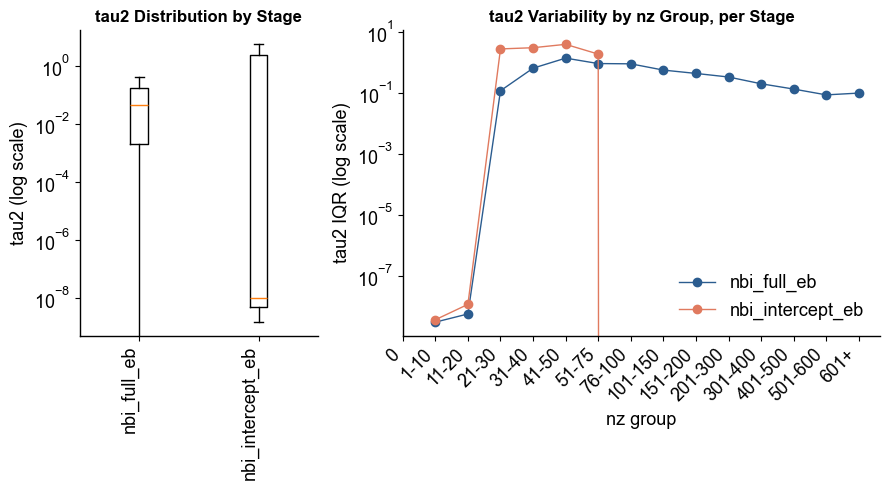

In [19]:
# 7. Batch Variance (tau2): distribution by stage + nz-level variability, one panel
ok_summ = summ[summ['ok']]
stage_groups = [s for s in ['nbi_full_eb', 'nbi_intercept_eb'] if s in ok_summ['stage'].unique()]
stage_colors = {'nbi_full_eb': '#2b5c8f', 'nbi_intercept_eb': '#e07a5f'}

fig, axes = plt.subplots(1, 2, figsize=(9, 5), width_ratios=[1,2])

tau2_by_stage = [ok_summ.loc[ok_summ['stage'] == s, 'tau2'].dropna() for s in stage_groups]
axes[0].boxplot(tau2_by_stage, tick_labels=stage_groups, showfliers=False)
axes[0].set_yscale('log')
axes[0].set_ylabel('tau2 (log scale)')
axes[0].set_title('tau2 Distribution by Stage', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(stage_groups, rotation=90, ha='right')

for stage in stage_groups:
    g_stage = ok_summ[ok_summ['stage'] == stage]
    tau2 = g_stage['tau2'].values
    nz_bin = pd.cut(g_stage['nz'].values, bins=bins, labels=labels)
    present_idx, iqr_by_bin = [], []
    for bi, lbl in enumerate(labels):
        mask = np.asarray(nz_bin == lbl)
        if not mask.any():
            continue
        q75, q25 = np.percentile(tau2[mask], [75, 25])
        present_idx.append(bi)
        iqr_by_bin.append(q75 - q25)
    axes[1].plot(present_idx, iqr_by_bin, marker='o', color=stage_colors[stage], label=stage)

axes[1].set_yscale('log')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_ylabel('tau2 IQR (log scale)')
axes[1].set_xlabel('nz group')
axes[1].set_title('tau2 Variability by nz Group, per Stage', fontsize=12, fontweight='bold')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [20]:
'''
8. Continuous Shrinkage vs Discrete Model Selection
The cascade only demotes nbi_full_eb -> nbi_intercept_eb on non-convergence (is_converged in
glmm_helpers.R), never on model comparison. The disp slopes DO carry a normal(0, tau_slope)
EB prior though (glmm_fit.R), which continuously shrinks unsupported slopes toward 0. Question:
among genes that converged as nbi_full_eb, how many are already statistically indistinguishable
from an intercept-only disp submodel (all 10 slope Wald z below threshold)? If most are, the
continuous shrinkage is already doing the discrete selection's job.
'''

Z_THR = 1.96
full_ok_genes = summ.loc[(summ['stage'] == 'nbi_full_eb') & (summ['ok']), 'gene'].values

z_rows = []
for g in full_ok_genes:
    fo = genes_fit[g]
    coef, se = fo.disp_coef, fo.disp_se
    if coef is None or se is None:
        continue
    slope_c, slope_se = coef[1:], se[1:]
    if np.all(np.isnan(slope_c)) or np.all(np.isnan(slope_se)):
        continue
    z_rows.append((g, slope_c / slope_se))

shrink_genes = [r[0] for r in z_rows]
Zw = np.array([r[1] for r in z_rows])  # (n_genes, 10), NaN where SE unusable (squeeze -> trend limit)
n_sig = np.nansum(np.abs(Zw) > Z_THR, axis=1)

print(f'nbi_full_eb & ok genes: {len(full_ok_genes)}')
print(f'usable disp_se (>=1 finite slope z): {len(shrink_genes)} ({len(shrink_genes) / len(full_ok_genes):.1%})')
print(f'genes with 0 significant slopes (|z|<{Z_THR} on all 10 covariates, '
      f'i.e. effectively intercept-only despite routing full): {(n_sig == 0).mean():.1%}')
print(f'genes with >=1 significant slope: {(n_sig >= 1).mean():.1%}')
print(f'median significant slopes per gene: {np.median(n_sig):.1f} / {Zw.shape[1]}')

nbi_full_eb & ok genes: 19011
usable disp_se (>=1 finite slope z): 19004 (100.0%)
genes with 0 significant slopes (|z|<1.96 on all 10 covariates, i.e. effectively intercept-only despite routing full): 7.2%
genes with >=1 significant slope: 92.8%
median significant slopes per gene: 4.0 / 10


/tmp/ipykernel_691136/527992625.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frac_by_bin = pd.Series(all_insig).groupby(nz_bin_shrink).mean().reindex(labels)


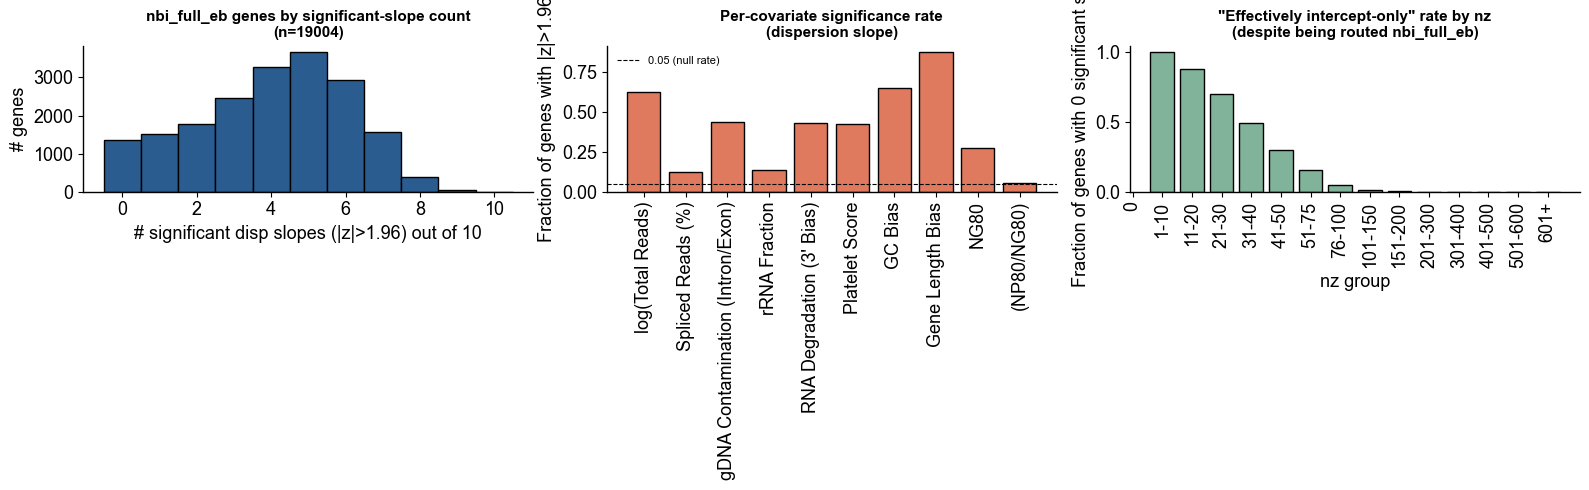

In [21]:
shrink_summ = summ.set_index('gene').loc[shrink_genes]
nz_bin_shrink = pd.cut(shrink_summ['nz'].values, bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution of # significant slopes per gene
axes[0].hist(n_sig, bins=np.arange(Zw.shape[1] + 2) - 0.5, color='#2b5c8f', edgecolor='black')
axes[0].set_xlabel('# significant disp slopes (|z|>1.96) out of 10')
axes[0].set_ylabel('# genes')
axes[0].set_title(f'nbi_full_eb genes by significant-slope count\n(n={len(shrink_genes)})', fontsize=11, fontweight='bold')

# 2. Per-covariate significant fraction (0.05 = chance rate under a true null)
sig_frac_by_cov = np.nanmean(np.abs(Zw) > Z_THR, axis=0)
axes[1].bar(coef_names, sig_frac_by_cov, color='#e07a5f', edgecolor='black')
axes[1].axhline(0.05, color='black', linewidth=0.8, linestyle='--', label='0.05 (null rate)')
axes[1].set_ylabel('Fraction of genes with |z|>1.96')
axes[1].set_title('Per-covariate significance rate\n(dispersion slope)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(frameon=False, fontsize=8)

# 3. "All-insignificant" (effectively-intercept-only) fraction by nz -- does shrinkage strength
# track data volume, or is it flat (i.e. driven by the prior alone, not the data)?
all_insig = (n_sig == 0)
frac_by_bin = pd.Series(all_insig).groupby(nz_bin_shrink).mean().reindex(labels)
axes[2].bar(labels, frac_by_bin.values, color='#81b29a', edgecolor='black')
axes[2].set_ylabel('Fraction of genes with 0 significant slopes')
axes[2].set_xlabel('nz group')
axes[2].set_title('"Effectively intercept-only" rate by nz\n(despite being routed nbi_full_eb)', fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

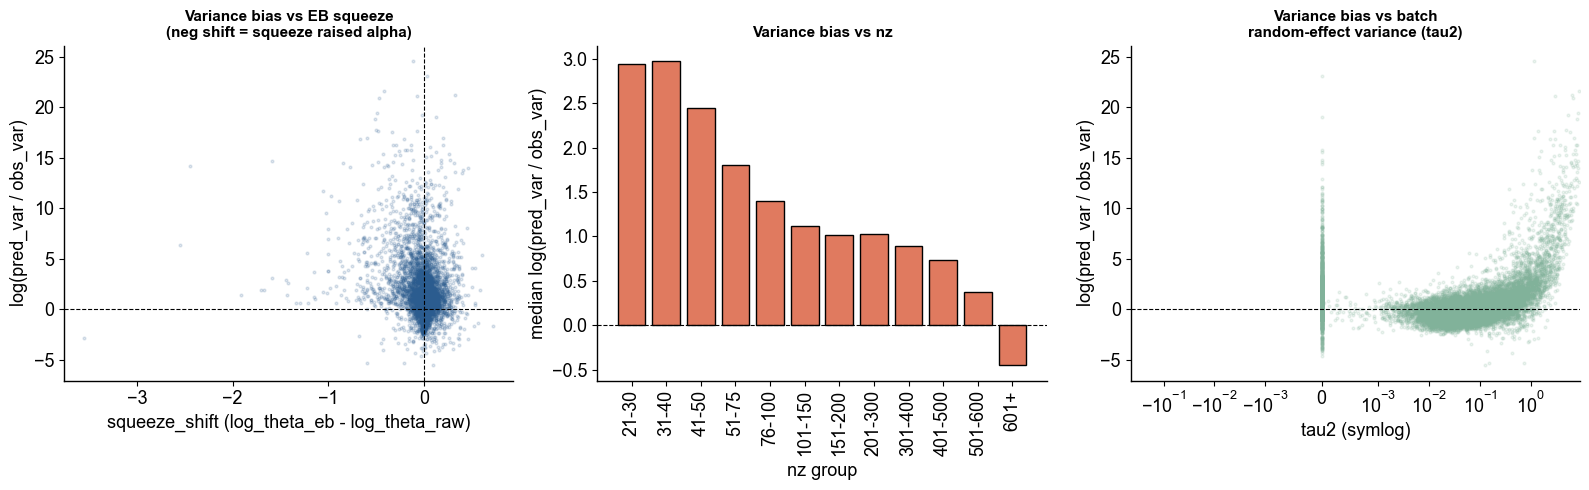

n genes with squeeze info: 18031 / 18031
corr(squeeze_shift, log_var_ratio) = -0.214
corr(tau2, log_var_ratio) = 0.660
median log_var_ratio by stage:
stage_failure
nbi_full_eb_True         0.252028
nbi_intercept_eb_True    8.590705
Name: log_var_ratio, dtype: float64


In [23]:
squeeze_rows = []
for g in ok_res['gene'].values:
    fo = genes_fit.get(g)
    if fo is None or fo.log_theta_raw is None or fo.log_theta_eb is None:
        continue
    squeeze_rows.append((g, fo.log_theta_raw, fo.log_theta_eb, fo.log_theta_eb - fo.log_theta_raw))

squeeze_df = pd.DataFrame(squeeze_rows, columns=['gene', 'log_theta_raw', 'log_theta_eb', 'squeeze_shift'])
diag = ok_res.merge(squeeze_df, on='gene', how='inner').merge(summ[['gene', 'tau2']], on='gene', how='inner')
diag['log_var_ratio'] = np.log(diag['pred_var'] / diag['obs_var'])  # >0 : variance over-predicted
nz_bin_diag = pd.cut(diag['nz'].values, bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A. Bias vs squeeze magnitude/direction (hypothesis a)
axes[0].scatter(diag['squeeze_shift'], diag['log_var_ratio'], s=4, alpha=0.15, color='#2b5c8f')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('squeeze_shift (log_theta_eb - log_theta_raw)')
axes[0].set_ylabel('log(pred_var / obs_var)')
axes[0].set_title('Variance bias vs EB squeeze\n(neg shift = squeeze raised alpha)', fontsize=11, fontweight='bold')

# B. Does the bias track nz (squeeze weight ~ SE^2, shrinks as own data grows)?
med_by_nz = diag.groupby(nz_bin_diag, observed=True)['log_var_ratio'].median().reindex(labels)
axes[1].bar(labels, med_by_nz.values, color='#e07a5f', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('median log(pred_var / obs_var)')
axes[1].set_xlabel('nz group')
axes[1].set_title('Variance bias vs nz', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

# C. Bias vs batch random-effect variance (hypothesis b)
axes[2].scatter(diag['tau2'], diag['log_var_ratio'], s=4, alpha=0.15, color='#81b29a')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xscale('symlog', linthresh=1e-3)
axes[2].set_xlabel('tau2 (symlog)')
axes[2].set_ylabel('log(pred_var / obs_var)')
axes[2].set_title('Variance bias vs batch\nrandom-effect variance (tau2)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'n genes with squeeze info: {len(diag)} / {len(ok_res)}')
print(f"corr(squeeze_shift, log_var_ratio) = {diag['squeeze_shift'].corr(diag['log_var_ratio']):.3f}")
print(f"corr(tau2, log_var_ratio) = {diag['tau2'].corr(diag['log_var_ratio']):.3f}")
print('median log_var_ratio by stage:')
print(diag.groupby('stage_failure')['log_var_ratio'].median())

nbi_full_eb_True genes (nz>=30): 18007
             median  count
tau2_bin                  
~0         0.752706   3813
0-0.1     -0.265970   7933
0.1-0.3    0.188055   3271
0.3-0.5    0.781766   1064
0.5-1      1.541064    978
1-1.5      2.495443    356
1.5-2      3.575631    183
2-3        5.254704    191
3-5        8.471638    160
5-9       12.107259     58


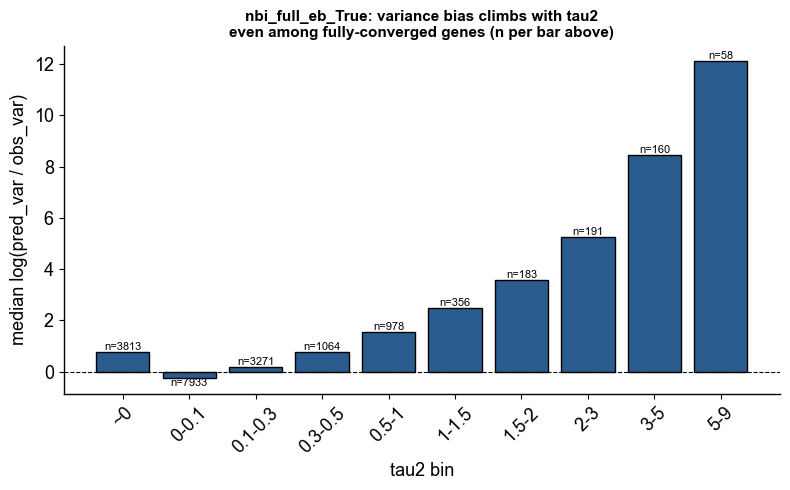

In [24]:
fe_diag = diag[diag['stage_failure'] == 'nbi_full_eb_True'].copy()
tau2_edges = [-0.001, 0.0001, 0.1, 0.3, 0.5, 1, 1.5, 2, 3, 5, 9, 100]
tau2_labels = ['~0', '0-0.1', '0.1-0.3', '0.3-0.5', '0.5-1', '1-1.5', '1.5-2', '2-3', '3-5', '5-9', '9+']
fe_diag['tau2_bin'] = pd.cut(fe_diag['tau2'], bins=tau2_edges, labels=tau2_labels)

tau2_tbl = fe_diag.groupby('tau2_bin', observed=True)['log_var_ratio'].agg(['median', 'count'])
print(f"nbi_full_eb_True genes (nz>={NZ_DIAG_MIN}): {len(fe_diag)}")
print(tau2_tbl)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tau2_tbl.index.astype(str), tau2_tbl['median'], color='#2b5c8f', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('median log(pred_var / obs_var)')
ax.set_xlabel('tau2 bin')
ax.set_title('nbi_full_eb_True: variance bias climbs with tau2\neven among fully-converged genes (n per bar above)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, (lbl, row) in enumerate(tau2_tbl.iterrows()):
    ax.text(i, row['median'], f"n={int(row['count'])}", ha='center',
            va='bottom' if row['median'] >= 0 else 'top', fontsize=8)
plt.tight_layout()
plt.show()

n genes analyzed: 18031
              n  median_tau2  median_log_var_ratio  frac_extreme
maxsz_bin                                                       
4-5          43     0.261477              0.488294      0.116279
6-10         66     0.611264              2.028055      0.409091
11-20        46     0.167561              1.543469      0.413043
21-50      8249     0.050922              0.244767      0.105104
51+        9627     0.046460              0.248575      0.091825

corr(log(max_batch_size), log_var_ratio) = -0.102


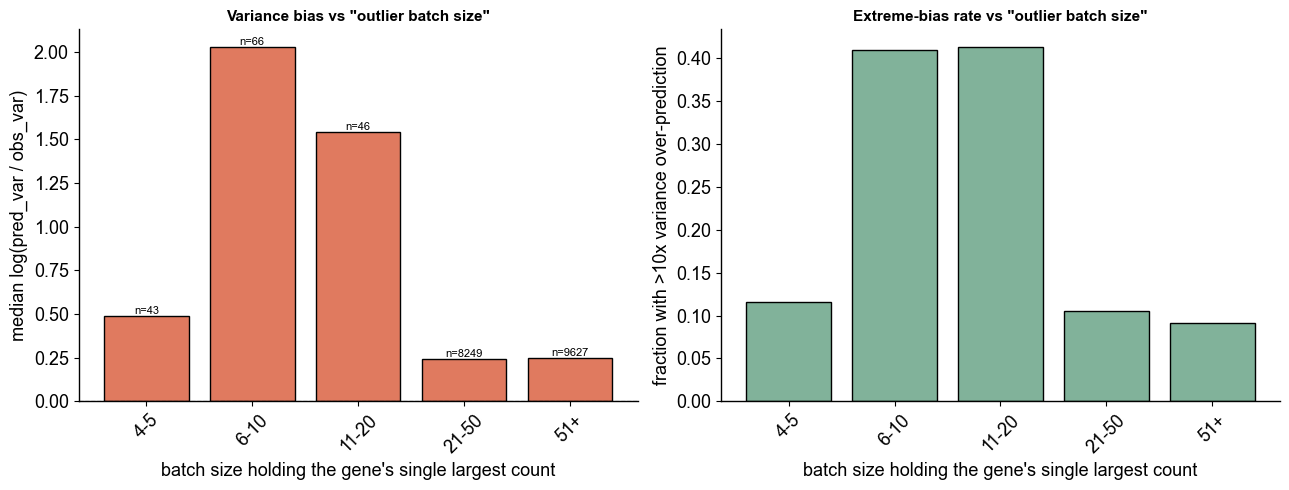

In [25]:
bsize = pd.Series(batch).value_counts()
batch_size_of_sample = np.array([bsize[b] for b in batch])

max_batch_rows = []
for g in diag['gene'].values:
    y = Y[:, gmap[g]]
    j = int(np.argmax(y))
    max_batch_rows.append((g, batch_size_of_sample[j]))
maxsz_df = pd.DataFrame(max_batch_rows, columns=['gene', 'max_batch_size'])
diag2 = diag.merge(maxsz_df, on='gene', how='inner')

sz_edges = [0, 1, 3, 5, 10, 20, 50, 700]
sz_labels = ['1 (singleton)', '2-3', '4-5', '6-10', '11-20', '21-50', '51+']
diag2['maxsz_bin'] = pd.cut(diag2['max_batch_size'], bins=sz_edges, labels=sz_labels)

sz_tbl = diag2.groupby('maxsz_bin', observed=True).agg(
    n=('gene', 'size'), median_tau2=('tau2', 'median'),
    median_log_var_ratio=('log_var_ratio', 'median'),
    frac_extreme=('log_var_ratio', lambda s: (s > np.log(10)).mean()))
print(f'n genes analyzed: {len(diag2)}')
print(sz_tbl)
print()
print(f"corr(log(max_batch_size), log_var_ratio) = {np.log(diag2['max_batch_size']).corr(diag2['log_var_ratio']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(sz_tbl.index.astype(str), sz_tbl['median_log_var_ratio'], color='#e07a5f', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('median log(pred_var / obs_var)')
axes[0].set_xlabel("batch size holding the gene's single largest count")
axes[0].set_title('Variance bias vs "outlier batch size"', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, (lbl, row) in enumerate(sz_tbl.iterrows()):
    axes[0].text(i, row['median_log_var_ratio'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)

axes[1].bar(sz_tbl.index.astype(str), sz_tbl['frac_extreme'], color='#81b29a', edgecolor='black')
axes[1].set_ylabel('fraction with >10x variance over-prediction')
axes[1].set_xlabel("batch size holding the gene's single largest count")
axes[1].set_title('Extreme-bias rate vs "outlier batch size"', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

ok genes with usable coefficients: 19130
y_crit quantiles (counts needed for z=3): {0.5: 150, 0.9: 1141, 0.99: 12502}
unreachable (y_crit > gene's own observed max): 113 (0.59%)


,n,mu_med,nz_med,ycrit_med,gmax_med,frac_unreach
tau2_bin,,,,,,
~0,4698,0.639,115.0,25.0,291.0,0.000
0-0.1,7937,63.084,639.0,266.0,1954.0,0.000
0.1-0.3,3281,42.447,622.0,304.0,2156.0,0.000
0.3-0.5,1071,6.814,403.0,154.0,1165.0,0.000
0.5-1,1004,0.790,175.5,48.0,479.0,0.008
1-1.5,383,0.260,97.0,30.0,240.0,0.042
1.5-2,213,0.127,71.0,25.0,161.0,0.056
2-2.5,144,0.093,70.0,26.0,140.0,0.056
2.5-3,94,0.059,52.5,21.5,155.0,0.032


,tau2_max,n_removed,pct_removed,n_unreach_removed,recall,precision
0,0.5,2143,11.2023,112,0.9912,0.0523
1,1.0,1139,5.9540,104,0.9204,0.0913
2,1.5,756,3.9519,88,0.7788,0.1164
3,2.0,543,2.8385,76,0.6726,0.1400
4,2.5,399,2.0857,68,0.6018,0.1704
5,3.0,305,1.5944,65,0.5752,0.2131
6,3.5,231,1.2075,53,0.4690,0.2294
7,4.0,172,0.8991,45,0.3982,0.2616
8,5.0,105,0.5489,31,0.2743,0.2952
9,6.0,73,0.3816,20,0.1770,0.2740


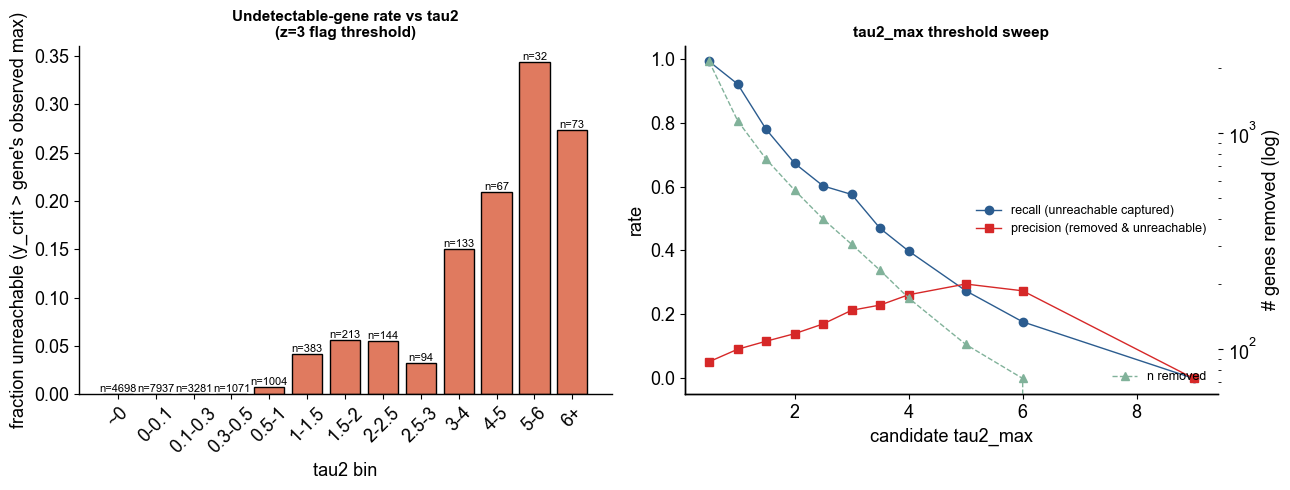

In [27]:
'''
13. Choosing tau2_max: which genes are actually undetectable?
Section 11 showed variance over-prediction climbing monotonically with tau2, but Section 3's
per-bin RQR check (rqr_msq ~1, cov_95 ~0.96, exceed ~0.05 at every tau2 including 5+) says the
Z-scores stay calibrated -- pred_var explodes as exp(2*tau2) while the QUANTILES barely move,
so the variance panel is a moment artifact, not miscalibration. The real cost of a large tau2 is
POWER: the predictive distribution gets so wide that no observable count reaches |z|=3.
'''
from scipy.stats import nbinom, norm

Z_DETECT = 3.0
GMAX_CACHE = ENGINE_PATH+'/gene_max_counts.csv'

def gene_max_counts():
    if os.path.exists(GMAX_CACHE):
        return pd.read_csv(GMAX_CACHE, index_col=0).iloc[:, 0]
    a = ad.read_h5ad(config.H5AD_PATH)
    m = ((a.obs['QC_Passed'] == True) & a.obs['Phenotype_Processed'].notna() &
         (a.obs['Phenotype_Processed'] != 'Unknown') &
         (a.obs['broad_protocol_category'] != 'Exome-based (EB)'))
    Xa = a[m].X
    Xa = Xa.toarray() if issparse(Xa) else np.asarray(Xa)
    out = pd.Series(np.round(Xa).max(0), index=a.var_names, name='gmax')
    out.to_csv(GMAX_CACHE)
    return out

def marginal_quantile_count(mu, alpha, tau2, p):
    # Smallest integer y with P(Y <= y-1) >= p under the same 7-node Gauss-Hermite lognormal-NB
    # mixture as nb_marginal_pmf0. Binary search on integers, vectorised across genes.
    n_ = 1.0 / np.maximum(alpha, 1e-8)
    sd = np.sqrt(np.maximum(tau2, 0.0))
    def cdf(y):
        tot = np.zeros(len(mu))
        for node, w in zip(_HG_NODES, _HG_WEIGHTS):
            mu_b = mu * np.exp(sd * node)
            tot += w * nbinom.cdf(y, n_, np.clip(n_ / (n_ + mu_b), 1e-12, 1 - 1e-12))
        return tot
    lo, hi = np.zeros(len(mu)), np.full(len(mu), 1e13)
    for _ in range(60):
        mid = np.floor((lo + hi) / 2)
        hit = cdf(mid - 1) >= p
        hi = np.where(hit, mid, hi)
        lo = np.where(hit, lo, mid + 1)
    return hi

ok_genes = summ.loc[summ['ok'], 'gene'].values
rows = []
for g in ok_genes:
    fo = genes_fit[g]
    if fo.mu_coef is None or fo.disp_coef is None:
        continue
    mu_i = np.exp(X_design @ np.nan_to_num(fo.mu_coef, nan=0.0))
    al_i = np.exp(-X_design @ np.nan_to_num(fo.disp_coef, nan=0.0))
    rows.append((g, np.median(mu_i), np.median(al_i), fo.tau2 or 0.0))

pw = pd.DataFrame(rows, columns=['gene', 'mu', 'alpha', 'tau2'])
pw['ycrit'] = marginal_quantile_count(pw['mu'].to_numpy(), np.clip(pw['alpha'].to_numpy(), 1e-8, None),
                                      pw['tau2'].to_numpy(), norm.cdf(Z_DETECT))
pw['gmax_obs'] = pw['gene'].map(gene_max_counts())
pw['reach'] = pw['ycrit'] / np.maximum(pw['gmax_obs'], 1)   # >1 : never observable for this gene
pw = pw.merge(summ[['gene', 'nz']], on='gene')

tau2_edges = [-1e-9, 1e-4, 0.1, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 100]
tau2_labels = ['~0', '0-0.1', '0.1-0.3', '0.3-0.5', '0.5-1', '1-1.5', '1.5-2', '2-2.5',
               '2.5-3', '3-4', '4-5', '5-6', '6+']
pw['tau2_bin'] = pd.cut(pw['tau2'], bins=tau2_edges, labels=tau2_labels)

tbl = pw.groupby('tau2_bin', observed=True).agg(
    n=('gene', 'size'), mu_med=('mu', 'median'), nz_med=('nz', 'median'),
    ycrit_med=('ycrit', 'median'), gmax_med=('gmax_obs', 'median'),
    frac_unreach=('reach', lambda v: (v > 1).mean()))
print(f'ok genes with usable coefficients: {len(pw)}')
print('y_crit quantiles (counts needed for z=3):',
      {q: int(pw['ycrit'].quantile(q)) for q in [0.5, 0.9, 0.99]})
print(f"unreachable (y_crit > gene's own observed max): {int((pw['reach'] > 1).sum())} "
      f"({(pw['reach'] > 1).mean():.2%})")
display(tbl.round(3))

# Threshold sweep: a tau2_max cut removes every gene above it. Precision = share of removed genes
# that are genuinely unreachable; recall = share of all unreachable genes the cut captures.
n_unreach = int((pw['reach'] > 1).sum())
sweep = []
for thr in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 9]:
    rm = pw['tau2'] > thr
    hit = rm & (pw['reach'] > 1)
    sweep.append({'tau2_max': thr, 'n_removed': int(rm.sum()), 'pct_removed': rm.mean() * 100,
                  'n_unreach_removed': int(hit.sum()),
                  'recall': hit.sum() / max(n_unreach, 1),
                  'precision': hit.sum() / max(rm.sum(), 1)})
sweep = pd.DataFrame(sweep)
display(sweep.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(tbl.index.astype(str), tbl['frac_unreach'], color='#e07a5f', edgecolor='black')
axes[0].set_ylabel("fraction unreachable (y_crit > gene's observed max)")
axes[0].set_xlabel('tau2 bin')
axes[0].set_title(f'Undetectable-gene rate vs tau2\n(z={Z_DETECT:g} flag threshold)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, (_, r) in enumerate(tbl.iterrows()):
    axes[0].text(i, r['frac_unreach'], f"n={int(r['n'])}", ha='center', va='bottom', fontsize=8)

axes[1].plot(sweep['tau2_max'], sweep['recall'], marker='o', color='#2b5c8f', label='recall (unreachable captured)')
axes[1].plot(sweep['tau2_max'], sweep['precision'], marker='s', color='#d62828', label='precision (removed & unreachable)')
ax2 = axes[1].twinx()
ax2.plot(sweep['tau2_max'], sweep['n_removed'], marker='^', color='#81b29a', linestyle='--', label='n removed')
ax2.set_yscale('log'); ax2.set_ylabel('# genes removed (log)')
axes[1].set_xlabel('candidate tau2_max'); axes[1].set_ylabel('rate')
axes[1].set_title('tau2_max threshold sweep', fontsize=11, fontweight='bold')
axes[1].legend(frameon=False, fontsize=9, loc='center right')
ax2.legend(frameon=False, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()